# Tugas Analisis Numerik — Volume Kedua Lambung Perahu Katamaran

**Nama:** Muhammad Za'im Nabil  

**NPM**: 25083010022   

**Mata kuliah:** Analisis Numerik   

**Link Github:** https://github.com/ZNabiilll/Analisis-Numerik-Volume-Lambung-Kapal

## 1. Latar Belakang dan Soal

Diberikan gambar perahu katamaran (tampak atas dan tampak samping) yang ditumpangi grid putus-putus. Tugasnya adalah **menghitung volume kedua lambung** perahu.

Ketentuan dari soal:

1. Satu *dash-kosong* bernilai **5 + 5 cm = 10 cm**.
2. Lantai kapal dianggap **datar (tanpa keel)**, sehingga tampak depan setiap penampang lambung berbentuk **persegi panjang**.
3. Volume *reserve buoyancy* **tidak dihitung**.
4. Hasil diunggah ke repository GitHub yang sama dengan pengumpulan tugas pertama (tenggat 4 Oktober 2026, 18:00 WIB).

## 2. Landasan Teori

### 2.1 Volume sebagai integral luas penampang

Bayangkan lambung diiris-iris tegak lurus sumbu panjang kapal, seperti mengiris roti tawar. Tiap irisan punya luas penampang $A(s)$, dengan $s$ adalah posisi irisan sepanjang kapal. Volume adalah jumlah semua irisan tipis itu:

$$V = \int_{0}^{L} A(s)\, ds$$

Karena lantai datar, setiap penampang berbentuk persegi panjang. Jadi luasnya cukup:

$$A(s) = \text{lebar}(s) \times \text{tinggi}(s)$$

- **lebar(s)** dibaca dari **tampak atas** (jarak sisi atas ke sisi bawah lambung),
- **tinggi(s)** dibaca dari **tampak samping** (jarak garis dek ke dasar lambung).

### 2.2 Aturan Simpson 1/3 Komposit

Fungsi $A(s)$ tidak punya rumus, hanya kita ketahui nilainya di titik-titik pengukuran. Maka integralnya dihitung numerik. Dengan $n$ **genap** subinterval berjarak sama $h$:

$$V \approx \frac{h}{3}\Big[A_0 + 4(A_1 + A_3 + \dots + A_{n-1}) + 2(A_2 + A_4 + \dots + A_{n-2}) + A_n\Big]$$

Titik ganjil berbobot 4, titik genap di tengah berbobot 2, dan dua titik ujung berbobot 1. Simpson memperlakukan tiap pasangan interval sebagai parabola, sehingga lebih teliti daripada aturan trapesium untuk lengkungan halus seperti badan perahu.

### 2.3 Aturan Trapesium Komposit (metode pembanding)

Sebagai **pembanding**, volume juga dihitung dengan aturan trapesium. Tiap interval diperlakukan sebagai trapesium (garis lurus antara dua titik), dengan $n$ subinterval berjarak sama $h$:

$$V \approx \frac{h}{2}\Big[A_0 + 2(A_1 + A_2 + \dots + A_{n-1}) + A_n\Big]$$

Bobot 1 untuk dua titik ujung dan bobot 2 untuk semua titik di tengah. Aturan ini lebih sederhana tetapi kurang teliti pada kurva melengkung, karena hanya memakai garis lurus. Jika hasil Simpson dan trapesium berdekatan, hasil hitungan bisa dipercaya karena dua metode berbeda memberi jawaban yang konsisten.

## 3. Pengukuran dari Gambar

### 3.1 Skala

Pada gambar, satu kotak grid ternyata berisi sekitar **4,2 dash-kosong**. Karena satu dash-kosong = 10 cm, maka:

$$1 \text{ kotak} \approx 4{,}2 \times 10 = 42 \text{ cm}$$

### 3.2 Titik pengamatan (stasiun)

Panjang lambung dibaca **21 kotak** (dari ujung buritan sampai ujung haluan). Lambung dibagi menjadi **14 interval** dengan jarak antar stasiun **h = 1,5 kotak**, sehingga ada **15 stasiun** ($s = 0; 1{,}5; 3; \dots; 21$). Jumlah interval genap, sehingga syarat Simpson 1/3 terpenuhi.

Di setiap stasiun, dibaca secara visual (satuan kotak, ketelitian sekitar 0,05 kotak):

- **lebar** lambung dari gambar *tampak atas*,
- **tinggi** lambung (dek sampai dasar) dari gambar *tampak samping*.

> Tampak samping hanya satu gambar, sehingga profil tinggi dipakai untuk kedua lambung (katamaran simetris). Lebar dibaca terpisah untuk lambung atas dan lambung bawah pada tampak atas.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter Skala

CM_PER_DASH   = 10      # 1 dash-kosong = 5 + 5 cm  (dari soal)
DASH_PER_KOTAK = 4.2    # hasil pembacaan: 1 kotak grid ~ 4,2 dash-kosong
CM_PER_KOTAK  = CM_PER_DASH * DASH_PER_KOTAK   # = 42 cm
M_PER_KOTAK   = CM_PER_KOTAK / 100             # = 0,42 m

print(f"1 kotak grid = {CM_PER_KOTAK:.0f} cm = {M_PER_KOTAK:.2f} m")

1 kotak grid = 42 cm = 0.42 m


In [11]:
# Data Hasil Pembacaan Gambar (satuan: kotak grid)

H_KOTAK = 1.5      # jarak antar stasiun (kotak)
N = 14             # jumlah interval (harus genap)

# posisi stasiun sepanjang kapal: 0; 1,5; 3; ...; 21
posisi = np.arange(0, N + 1) * H_KOTAK

# Lebar lambung dari TAMPAK ATAS (kotak)
lebar_atas = np.array([1.15, 1.45, 1.75, 1.90, 2.00, 2.00, 2.05, 2.05,
                       2.05, 2.00, 1.95, 1.65, 1.30, 0.85, 0.00])   # lambung atas
lebar_bawah = np.array([1.15, 1.45, 1.75, 1.90, 2.00, 2.00, 2.05, 2.05,
                        2.05, 2.00, 1.95, 1.60, 1.20, 0.80, 0.00])  # lambung bawah

# Tinggi lambung dari TAMPAK SAMPING (kotak): dek -> dasar
tinggi = np.array([0.75, 1.25, 1.90, 2.50, 2.55, 2.55, 2.55, 2.55,
                   2.55, 2.55, 2.55, 2.55, 2.55, 1.65, 0.00])

# Pemeriksaan data supaya tidak ada salah ketik
assert N % 2 == 0, "Simpson 1/3 butuh jumlah interval genap"
assert len(posisi) == len(lebar_atas) == len(lebar_bawah) == len(tinggi) == N + 1

print("Jumlah stasiun :", len(posisi))
print("Panjang lambung:", posisi[-1], "kotak =", posisi[-1] * M_PER_KOTAK, "m")

Jumlah stasiun : 15
Panjang lambung: 21.0 kotak = 8.82 m


## 4. Implementasi

### 4.1 Fungsi integrasi numerik

Dua fungsi dibuat sederhana: `simpson_13` (metode utama) dan `trapesium` (pembanding).

In [12]:
def simpson(y, h):
    """Integral numerik dengan Simpson 1/3 komposit.
    y : nilai fungsi di titik-titik berjarak sama (jumlah titik harus ganjil)
    h : jarak antar titik
    """
    n = len(y) - 1
    if n % 2 != 0:
        raise ValueError("Jumlah interval harus genap")
    ganjil = y[1:-1:2].sum()    # y1, y3, y5, ...  -> bobot 4
    genap  = y[2:-1:2].sum()    # y2, y4, y6, ...  -> bobot 2
    return (h / 3) * (y[0] + 4 * ganjil + 2 * genap + y[-1])


def trapesium(y, h):
    """Integral numerik dengan aturan trapesium (pembanding)."""
    return h * (y.sum() - 0.5 * (y[0] + y[-1]))

### 4.2 Konversi ke satuan meter dan luas penampang

Pembacaan dalam kotak diubah ke meter, lalu luas penampang tiap stasiun dihitung dengan $A = \text{lebar} \times \text{tinggi}$ (persegi panjang).

In [13]:
# Konversi kotak -> meter
h_m      = H_KOTAK * M_PER_KOTAK
lebar_a  = lebar_atas  * M_PER_KOTAK
lebar_b  = lebar_bawah * M_PER_KOTAK
tinggi_m = tinggi      * M_PER_KOTAK

# Luas penampang tiap stasiun: A = lebar x tinggi  (m^2)
A_atas  = lebar_a * tinggi_m
A_bawah = lebar_b * tinggi_m

print(f"h = {h_m:.3f} m")
print()
print(f"{'s (m)':>7} {'lebar atas':>11} {'lebar bwh':>10} {'tinggi':>8} {'A atas':>8} {'A bawah':>8}")
for s, la, lb, t, aa, ab in zip(posisi * M_PER_KOTAK, lebar_a, lebar_b, tinggi_m, A_atas, A_bawah):
    print(f"{s:7.2f} {la:11.3f} {lb:10.3f} {t:8.3f} {aa:8.3f} {ab:8.3f}")

h = 0.630 m

  s (m)  lebar atas  lebar bwh   tinggi   A atas  A bawah
   0.00       0.483      0.483    0.315    0.152    0.152
   0.63       0.609      0.609    0.525    0.320    0.320
   1.26       0.735      0.735    0.798    0.587    0.587
   1.89       0.798      0.798    1.050    0.838    0.838
   2.52       0.840      0.840    1.071    0.900    0.900
   3.15       0.840      0.840    1.071    0.900    0.900
   3.78       0.861      0.861    1.071    0.922    0.922
   4.41       0.861      0.861    1.071    0.922    0.922
   5.04       0.861      0.861    1.071    0.922    0.922
   5.67       0.840      0.840    1.071    0.900    0.900
   6.30       0.819      0.819    1.071    0.877    0.877
   6.93       0.693      0.672    1.071    0.742    0.720
   7.56       0.546      0.504    1.071    0.585    0.540
   8.19       0.357      0.336    0.693    0.247    0.233
   8.82       0.000      0.000    0.000    0.000    0.000


### 4.3 Menghitung volume

Luas penampang $A(s)$ diintegrasikan sepanjang kapal dengan Simpson 1/3.

In [14]:
# Volume dengan Simpson 1/3 (metode utama)
V_atas_simpson  = simpson_13(A_atas,  h_m)
V_bawah_simpson = simpson_13(A_bawah, h_m)

# Volume dengan trapesium (pembanding)
V_atas_trap  = trapesium(A_atas,  h_m)
V_bawah_trap = trapesium(A_bawah, h_m)

V_total_simpson = V_atas_simpson + V_bawah_simpson
V_total_trap    = V_atas_trap + V_bawah_trap

print("=== HASIL (Simpson 1/3) ===")
print(f"Volume lambung atas  : {V_atas_simpson:.3f} m^3  ({V_atas_simpson*1000:,.0f} liter)")
print(f"Volume lambung bawah : {V_bawah_simpson:.3f} m^3  ({V_bawah_simpson*1000:,.0f} liter)")
print(f"Volume total         : {V_total_simpson:.3f} m^3  ({V_total_simpson*1000:,.0f} liter)")
print()
print("=== PEMBANDING (Trapesium) ===")
print(f"Volume lambung atas  : {V_atas_trap:.3f} m^3")
print(f"Volume lambung bawah : {V_bawah_trap:.3f} m^3")
print(f"Volume total         : {V_total_trap:.3f} m^3")
print()
selisih = abs(V_total_simpson - V_total_trap) / V_total_simpson * 100
print(f"Selisih Simpson vs Trapesium: {selisih:.2f} %")

=== HASIL (Simpson 1/3) ===
Volume lambung atas  : 6.134 m^3  (6,134 liter)
Volume lambung bawah : 6.084 m^3  (6,084 liter)
Volume total         : 12.219 m^3  (12,219 liter)

=== PEMBANDING (Trapesium) ===
Volume lambung atas  : 6.134 m^3
Volume lambung bawah : 6.083 m^3
Volume total         : 12.217 m^3

Selisih Simpson vs Trapesium: 0.01 %


### 4.4 Visualisasi

Grafik di bawah memperlihatkan profil lebar, tinggi, dan luas penampang sepanjang kapal. Luas di bawah kurva $A(s)$ itulah volume lambung.

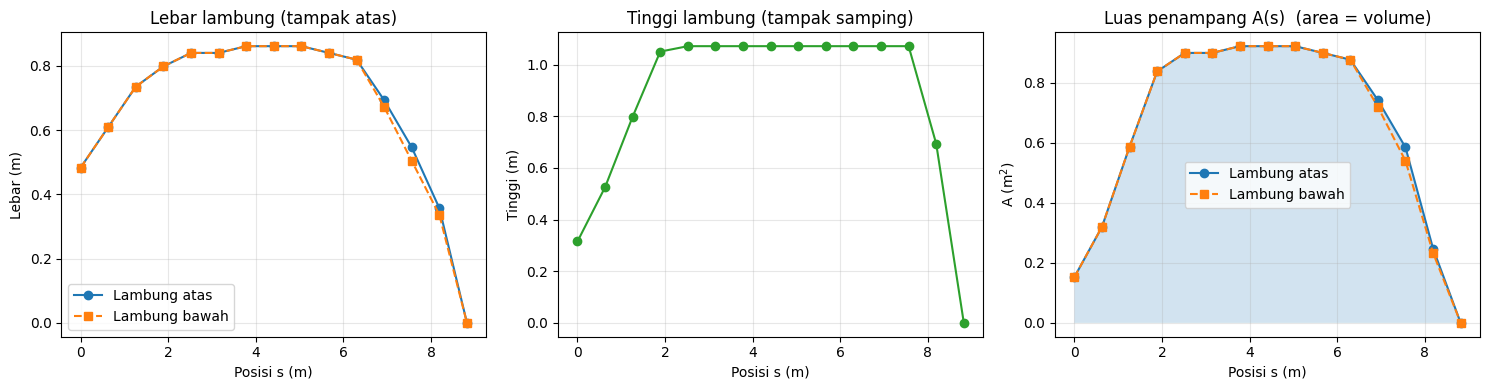

In [15]:
s_m = posisi * M_PER_KOTAK

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# (a) lebar lambung (tampak atas)
ax[0].plot(s_m, lebar_a, "o-", label="Lambung atas")
ax[0].plot(s_m, lebar_b, "s--", label="Lambung bawah")
ax[0].set_title("Lebar lambung (tampak atas)")
ax[0].set_xlabel("Posisi s (m)"); ax[0].set_ylabel("Lebar (m)"); ax[0].legend()

# (b) tinggi lambung (tampak samping)
ax[1].plot(s_m, tinggi_m, "o-", color="tab:green")
ax[1].set_title("Tinggi lambung (tampak samping)")
ax[1].set_xlabel("Posisi s (m)"); ax[1].set_ylabel("Tinggi (m)")

# (c) luas penampang -> area di bawah kurva = volume
ax[2].plot(s_m, A_atas, "o-", label="Lambung atas")
ax[2].plot(s_m, A_bawah, "s--", label="Lambung bawah")
ax[2].fill_between(s_m, A_atas, alpha=0.2)
ax[2].set_title("Luas penampang A(s)  (area = volume)")
ax[2].set_xlabel("Posisi s (m)"); ax[2].set_ylabel("A (m$^2$)"); ax[2].legend()

for a in ax: a.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Analisis Ketelitian

Selisih antara Simpson dan trapesium yang sangat kecil menandakan profil lambung cukup halus, sehingga 15 stasiun sudah memadai. Sumber galat utama dalam tugas ini bukan metode integrasinya, melainkan **pembacaan visual** (sekitar ±0,05 kotak). Di bawah, sensitivitasnya diuji.

In [16]:
# Uji sensitivitas: bagaimana jika semua pembacaan lebar & tinggi meleset +/- 0,05 kotak?
galat = 0.05
tinggi_plus  = np.clip(tinggi + galat, 0, None)
lebar_plus   = np.clip(lebar_atas + galat, 0, None)
tinggi_min   = np.clip(tinggi - galat, 0, None)
lebar_min    = np.clip(lebar_atas - galat, 0, None)

V_plus = simpson(lebar_plus * tinggi_plus * M_PER_KOTAK**2, h_m)
V_min  = simpson(lebar_min  * tinggi_min  * M_PER_KOTAK**2, h_m)

print(f"Volume lambung atas (data asli)    : {V_atas_simpson:.3f} m^3")
print(f"Volume jika pembacaan +{galat} kotak : {V_plus:.3f} m^3")
print(f"Volume jika pembacaan -{galat} kotak : {V_min:.3f} m^3")
print(f"Rentang ketidakpastian             : sekitar +/- {(V_plus - V_min)/2:.3f} m^3")

Volume lambung atas (data asli)    : 6.134 m^3
Volume jika pembacaan +0.05 kotak : 6.441 m^3
Volume jika pembacaan -0.05 kotak : 5.836 m^3
Rentang ketidakpastian             : sekitar +/- 0.303 m^3


## 6. Kesimpulan

Volume kedua lambung dihitung dengan mengiris lambung menjadi 15 stasiun (h = 1,5 kotak = 0,63 m), lalu mengubah luas penampang persegi panjang $A = \text{lebar} \times \text{tinggi}$ menjadi volume dengan **Simpson 1/3 komposit**. Dengan skala 1 kotak = 42 cm (1 dash-kosong = 10 cm), diperoleh:

| Lambung | Volume (m³) | Volume (liter) |
|---|---|---|
| Lambung atas | **6,13 m³** | 6.134 liter |
| Lambung bawah | **6,08 m³** | 6.084 liter |
| **Total kedua lambung** | **12,22 m³** | 12.219 liter |

Sebagai pembanding, volume yang sama dihitung dengan aturan trapesium:

| Lambung | Simpson 1/3 (m³) | Trapesium (m³) |
|---|---|---|
| Lambung atas | 6,134 | 6,134 |
| Lambung bawah | 6,084 | 6,083 |
| Total kedua lambung | 12,219 | 12,217 |

Kedua metode hampir sama (selisih total 0,01%), sehingga profil lambung cukup halus dan 15 stasiun sudah memadai. Ketidakpastian utama berasal dari pembacaan gambar secara visual (galat ±0,05 kotak menggeser volume satu lambung sekitar ±0,3 m³). Volume *reserve buoyancy* tidak dihitung sesuai ketentuan soal.

Jika skala atau data pembacaan diubah, ubah `DASH_PER_KOTAK` atau array data di sel data, jalankan ulang notebook, lalu sesuaikan angka pada tabel kesimpulan ini dengan keluaran sel "Menghitung volume".